# LeetCode #723: Candy Crush

https://leetcode.com/problems/candy-crush/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O((r \cdot c)^2)$ | $O(r \cdot c)$ |
| **In-place Marking** ★ | $O((r \cdot c)^2)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
In each pass, collect cells to crush into a separate set, zero them out, then copy the board to drop candies. Repeating this until stable costs $O(r \cdot c)$ auxiliary space for the copy.

### Optimal: In-place Marking ★
In each pass, **negate** every cell that belongs to a group of 3+ consecutive same-colored candies — horizontally and vertically — in a single sweep. Negation preserves the candy color via `abs()`, so H and V marking can run back-to-back without conflict. Then zero all negatives and compact each column downward with a two-pointer write. Repeat until no negations occur.

**Why this is better than Brute Force:** Eliminates the auxiliary board entirely. Both run in $O((r \cdot c)^2)$ time (at most $r \cdot c$ rounds, each $O(r \cdot c)$), but the negation trick keeps space at $O(1)$.

**Constraints:**
* 3 ≤ board.length ≤ 50
* 6 ≤ board[i].length ≤ 6
* 1 ≤ board[i][j] ≤ 5 (candy colors); 0 = empty cell

## Solutions

### C#

In [ ]:
public class Solution {
    public int[][] CandyCrush(int[][] board) {
        int rows = board.Length, cols = board[0].Length;
        bool stable = false;

        while (!stable) {
            stable = true;

            // Negate horizontal groups of 3+ — abs() still recovers the color
            for (int r = 0; r < rows; r++)
                for (int c = 0; c < cols - 2; c++) {
                    int v = Math.Abs(board[r][c]);
                    if (v != 0 && v == Math.Abs(board[r][c+1]) && v == Math.Abs(board[r][c+2])) {
                        stable = false;
                        board[r][c]   = -Math.Abs(board[r][c]);
                        board[r][c+1] = -Math.Abs(board[r][c+1]);
                        board[r][c+2] = -Math.Abs(board[r][c+2]);
                    }
                }

            // Negate vertical groups of 3+
            for (int r = 0; r < rows - 2; r++)
                for (int c = 0; c < cols; c++) {
                    int v = Math.Abs(board[r][c]);
                    if (v != 0 && v == Math.Abs(board[r+1][c]) && v == Math.Abs(board[r+2][c])) {
                        stable = false;
                        board[r][c]   = -Math.Abs(board[r][c]);
                        board[r+1][c] = -Math.Abs(board[r+1][c]);
                        board[r+2][c] = -Math.Abs(board[r+2][c]);
                    }
                }

            // Zero negatives and compact each column downward
            if (!stable)
                for (int c = 0; c < cols; c++) {
                    int write = rows - 1;
                    for (int r = rows - 1; r >= 0; r--)
                        if (board[r][c] > 0) board[write--][c] = board[r][c];
                    for (int r = write; r >= 0; r--)
                        board[r][c] = 0;
                }
        }
        return board;
    }
}

### Python

In [ ]:
class Solution:
    def candyCrush(self, board: List[List[int]]) -> List[List[int]]:
        rows, cols = len(board), len(board[0])
        stable = False

        while not stable:
            stable = True

            # Negate horizontal groups of 3+ — abs() still recovers the color
            for r in range(rows):
                for c in range(cols - 2):
                    v = abs(board[r][c])
                    if v and v == abs(board[r][c+1]) == abs(board[r][c+2]):
                        stable = False
                        board[r][c]   = -abs(board[r][c])
                        board[r][c+1] = -abs(board[r][c+1])
                        board[r][c+2] = -abs(board[r][c+2])

            # Negate vertical groups of 3+
            for r in range(rows - 2):
                for c in range(cols):
                    v = abs(board[r][c])
                    if v and v == abs(board[r+1][c]) == abs(board[r+2][c]):
                        stable = False
                        board[r][c]   = -abs(board[r][c])
                        board[r+1][c] = -abs(board[r+1][c])
                        board[r+2][c] = -abs(board[r+2][c])

            # Zero negatives and compact each column downward
            if not stable:
                for c in range(cols):
                    write = rows - 1
                    for r in range(rows - 1, -1, -1):
                        if board[r][c] > 0:
                            board[write][c] = board[r][c]
                            write -= 1
                    for r in range(write, -1, -1):
                        board[r][c] = 0

        return board

### Go

In [ ]:
func candyCrush(board [][]int) [][]int {
    rows, cols := len(board), len(board[0])
    stable := false

    for !stable {
        stable = true

        // Negate horizontal groups of 3+ — abs still recovers the color
        for r := 0; r < rows; r++ {
            for c := 0; c < cols-2; c++ {
                v := iAbs(board[r][c])
                if v != 0 && v == iAbs(board[r][c+1]) && v == iAbs(board[r][c+2]) {
                    stable = false
                    board[r][c]   = -iAbs(board[r][c])
                    board[r][c+1] = -iAbs(board[r][c+1])
                    board[r][c+2] = -iAbs(board[r][c+2])
                }
            }
        }

        // Negate vertical groups of 3+
        for r := 0; r < rows-2; r++ {
            for c := 0; c < cols; c++ {
                v := iAbs(board[r][c])
                if v != 0 && v == iAbs(board[r+1][c]) && v == iAbs(board[r+2][c]) {
                    stable = false
                    board[r][c]   = -iAbs(board[r][c])
                    board[r+1][c] = -iAbs(board[r+1][c])
                    board[r+2][c] = -iAbs(board[r+2][c])
                }
            }
        }

        // Zero negatives and compact each column downward
        if !stable {
            for c := 0; c < cols; c++ {
                write := rows - 1
                for r := rows - 1; r >= 0; r-- {
                    if board[r][c] > 0 {
                        board[write][c] = board[r][c]
                        write--
                    }
                }
                for r := write; r >= 0; r-- {
                    board[r][c] = 0
                }
            }
        }
    }
    return board
}

func iAbs(x int) int {
    if x < 0 { return -x }
    return x
}

### Rust

In [ ]:
pub fn candy_crush(mut board: Vec<Vec<i32>>) -> Vec<Vec<i32>> {
    let rows = board.len();
    let cols = board[0].len();
    let mut stable = false;

    while !stable {
        stable = true;

        // Negate horizontal groups of 3+ — abs() still recovers the color
        for r in 0..rows {
            for c in 0..cols - 2 {
                let v = board[r][c].abs();
                if v != 0 && v == board[r][c+1].abs() && v == board[r][c+2].abs() {
                    stable = false;
                    board[r][c]   = -board[r][c].abs();
                    board[r][c+1] = -board[r][c+1].abs();
                    board[r][c+2] = -board[r][c+2].abs();
                }
            }
        }

        // Negate vertical groups of 3+
        for r in 0..rows - 2 {
            for c in 0..cols {
                let v = board[r][c].abs();
                if v != 0 && v == board[r+1][c].abs() && v == board[r+2][c].abs() {
                    stable = false;
                    board[r][c]   = -board[r][c].abs();
                    board[r+1][c] = -board[r+1][c].abs();
                    board[r+2][c] = -board[r+2][c].abs();
                }
            }
        }

        // Zero negatives and compact each column downward
        if !stable {
            for c in 0..cols {
                let mut write = rows;
                for r in (0..rows).rev() {
                    if board[r][c] > 0 {
                        write -= 1;
                        board[write][c] = board[r][c];
                    }
                }
                for r in 0..write {
                    board[r][c] = 0;
                }
            }
        }
    }
    board
}

## Example Scenarios

**1. Common Case — simple horizontal triple**
**Input:** board = [[1,1,1],[2,3,4],[5,2,3]]
Row 0 has three 1s → marked (negated) → zeroed → columns compact downward. No more crushable groups after drop.
Output: [[0,0,0],[2,3,4],[5,2,3]]

**2. Slightly Complex — H and V groups in the same pass**
**Input:** board = [[1,2,1],[2,2,2],[1,2,3]]
Row 1 (2,2,2) → horizontal group. Col 1 (2,2,2 in rows 0,1,2) → vertical group. Both marked in one sweep (negation handles overlap at (1,1) cleanly via abs). After crush and drop: only the 1s and 3 remain at the bottom.
Output: [[0,0,0],[1,0,1],[1,0,3]] — wait, col 1 is all gone.
Output: [[0,0,0],[1,0,1],[1,0,3]]

**3. Edge Case: Time Factor — chain reaction across rounds**
**Input:** board = [[1,1,3],[3,1,1],[3,3,3]]
Round 1: row 2 (3,3,3) crushed; col 0 rows 0–1 (1,3) not a group yet. After drop: board = [[0,1,3],[1,1,1],[3,3,0]]. Round 2: row 1 (1,1,1) crushed. Two full rounds needed — each $O(r \cdot c)$ — demonstrating the $O((r \cdot c)^2)$ worst case.

**4. Edge Case: Space Factor — overlapping groups share negated cells**
**Input:** board = [[1,1,1],[1,2,3],[1,4,5]]
Col 0 rows 0–2 (1,1,1) → vertical group. Row 0 cols 0–2 (1,1,1) → horizontal group. Cell (0,0) belongs to both. Negation marks it once regardless of double-membership; `abs()` on the already-negated value still returns 1, so the second check also triggers correctly. Zero extra space needed.
Output: [[0,0,0],[0,2,3],[0,4,5]]

**5. Almost-Impossible but Plausible — already stable board, zero rounds**
**Input:** board = [[1,2,1],[2,1,2],[1,2,1]]
No cell has two neighbours of the same color in any direction (checkerboard pattern). `stable` stays true from the first iteration — the while loop body runs exactly once and exits immediately.
Output: [[1,2,1],[2,1,2],[1,2,1]] (unchanged)

## Infographic

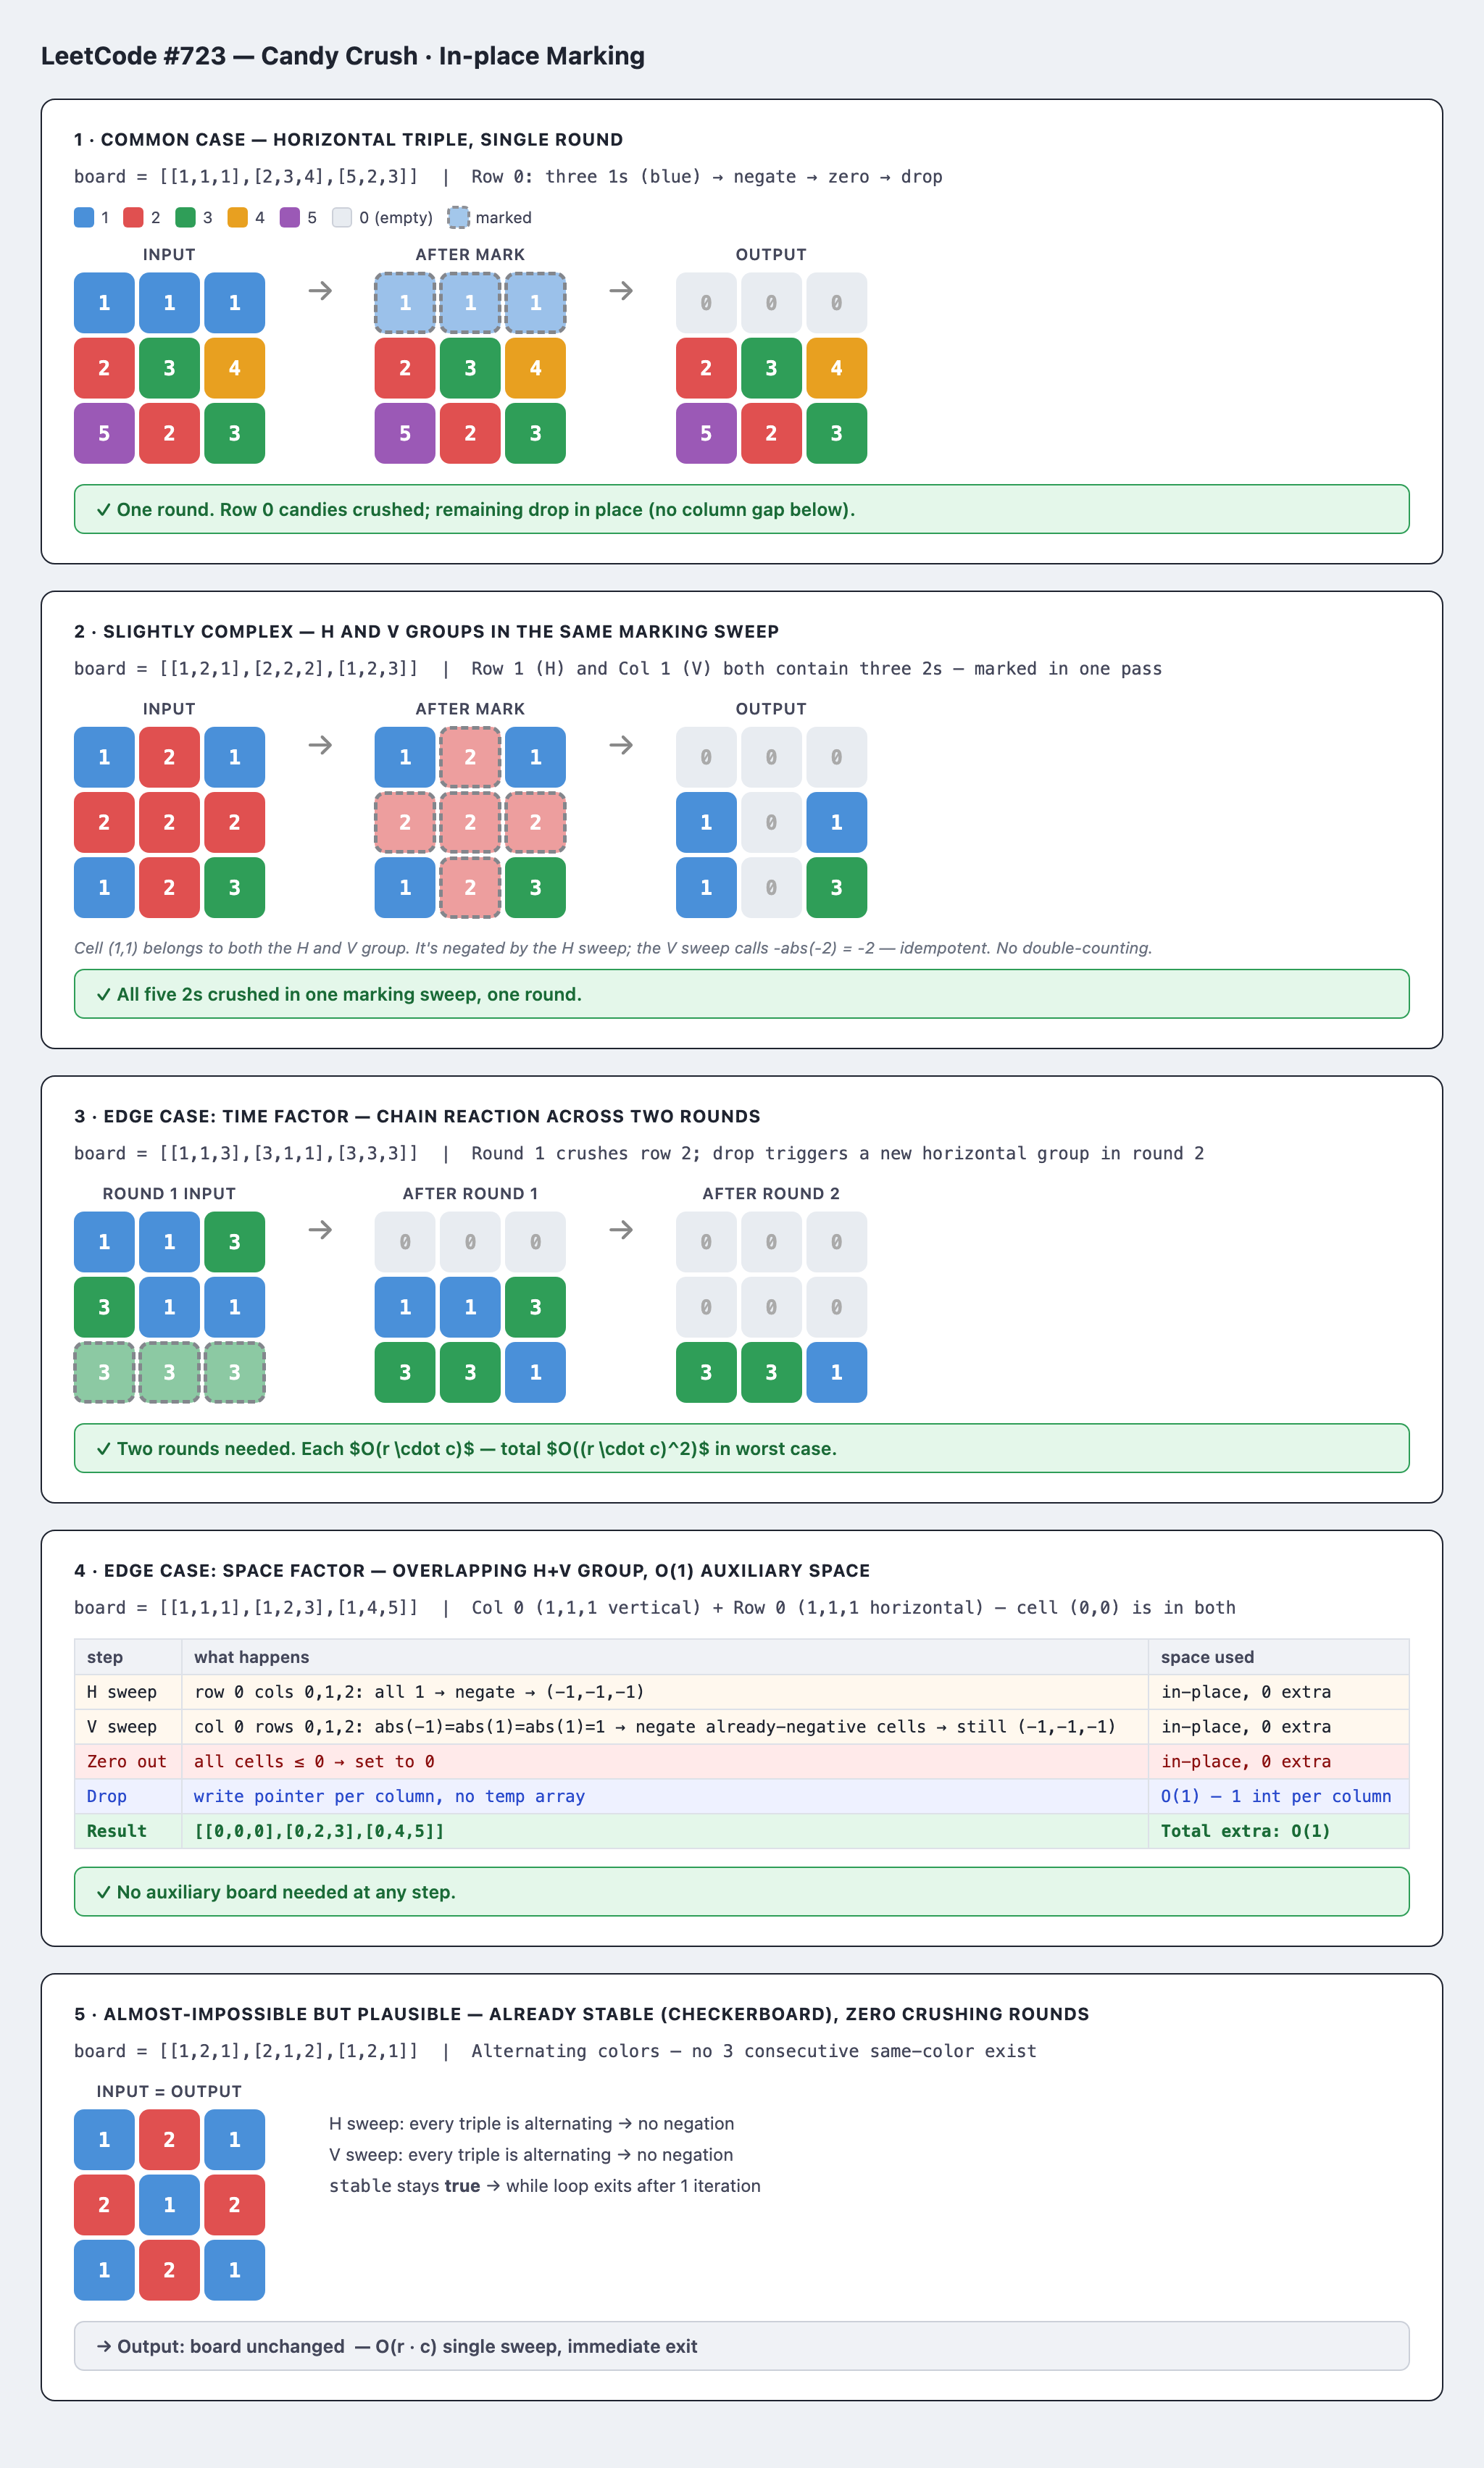